In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [3]:
# Exclude data with dates before 2015
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2015-12-31 23:00")]

In [4]:
# Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-01-01 00:00:00,0.0,-1.090,81.50,1.05200,52.27,0.63
2015-01-01 01:00:00,0.0,-1.038,81.70,0.95900,46.71,0.62
2015-01-01 02:00:00,0.0,-0.981,82.00,1.06200,52.04,0.60
2015-01-01 03:00:00,0.0,-0.814,81.90,0.88700,58.91,0.64
2015-01-01 04:00:00,0.0,-0.805,90.00,0.82800,16.55,0.20
...,...,...,...,...,...,...
2015-12-31 18:00:00,0.0,7.911,71.14,1.30800,41.84,7.73
2015-12-31 19:00:00,0.0,7.799,70.57,1.32800,42.85,0.00
2015-12-31 20:00:00,0.0,7.663,73.24,1.35075,41.22,0.00


In [5]:
df = df.resample('12H').mean()

In [6]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [7]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [8]:
df.head(10)

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-01-01 00:00:00,0.000000,-1.099000,91.966667,0.923733,48.920833,8.824167
2015-01-01 12:00:00,0.063500,0.696917,99.600000,1.513759,39.880000,26.603333
2015-01-02 00:00:00,0.063500,15.897234,100.000000,1.108231,38.247708,5.404167
2015-01-02 12:00:00,0.465667,1.654917,99.750000,1.441991,66.538542,26.579167
2015-01-03 00:00:00,0.063500,7.128337,93.169167,1.437333,65.956667,76.445833
2015-01-03 12:00:00,0.000000,11.719000,47.211667,1.584313,198.580000,254.937500
2015-01-04 00:00:00,0.000000,4.573583,70.568333,2.027250,67.267500,82.325000
2015-01-04 12:00:00,0.000000,4.185125,56.134167,1.878200,19.854500,255.050000
2015-01-05 00:00:00,0.000000,-2.648617,74.224167,0.596213,140.140833,87.185000


In [9]:
df.tail(10)

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-12-27 00:00:00,0.0,9.485917,91.683333,3.892804,151.819583,8.714167
2015-12-27 12:00:00,0.0,1.650333,93.125000,3.412069,130.340000,35.274167
2015-12-28 00:00:00,0.0,2.901197,79.689167,3.844708,54.997500,26.414167
2015-12-28 12:00:00,0.0,1.717000,78.821667,2.146167,197.458333,99.103333
2015-12-29 00:00:00,0.0,0.085542,89.469167,0.802657,218.923000,32.498333
2015-12-29 12:00:00,0.0,7.232750,71.634167,1.425056,159.541667,133.169167
2015-12-30 00:00:00,0.0,3.447867,94.925000,0.638778,169.030000,51.092500
2015-12-30 12:00:00,0.0,8.032167,77.170833,1.137292,133.308333,176.881667
2015-12-31 00:00:00,0.0,2.015167,94.508333,0.704444,128.371833,57.960833


In [10]:
df.shape

(730, 6)

## Visualization 

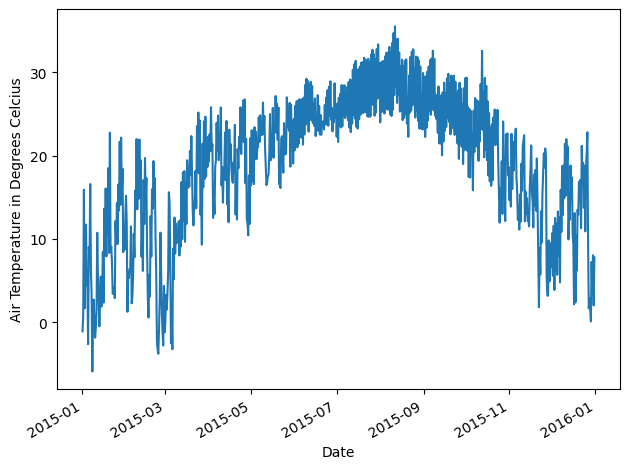

In [11]:
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature in Degrees Celcius')


fig.autofmt_xdate()
plt.tight_layout()



## Exploration 

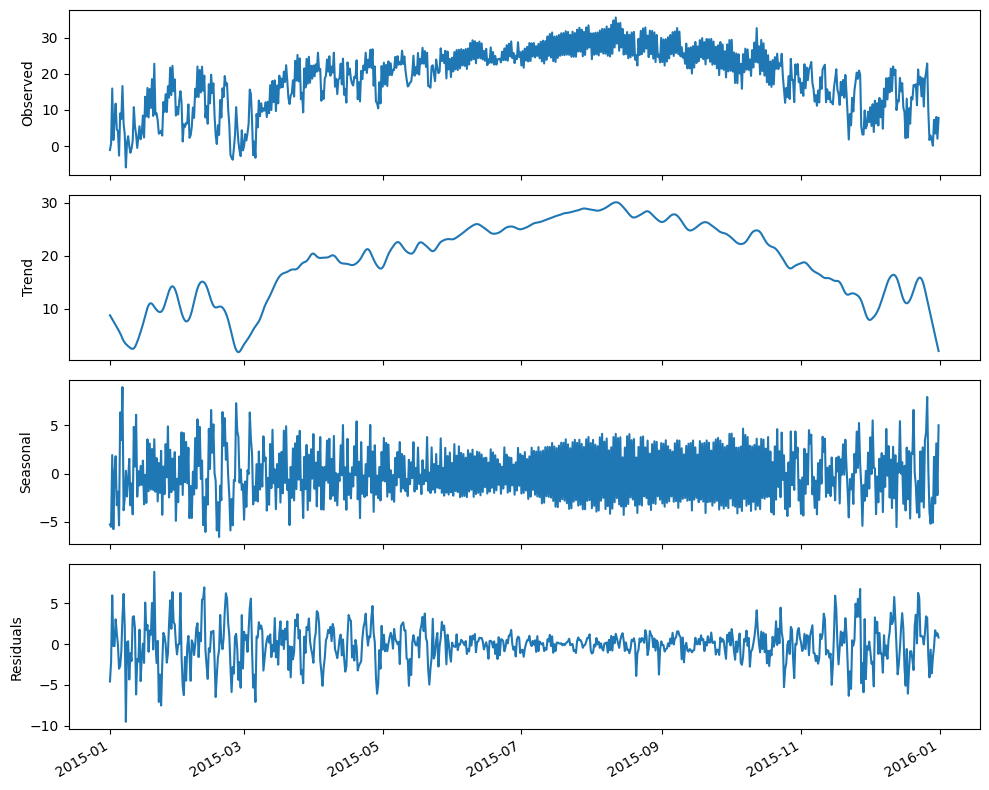

In [12]:
decomposition = STL(df.Tair, period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')


fig.autofmt_xdate()
plt.tight_layout()



## Modeling 

In [13]:
ad_fuller_result = adfuller(df.Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -1.8133187948388862
p-value: 0.3738696172925051


In [14]:
Tair_diff = np.diff(df.Tair, n=1)

ad_fuller_result = adfuller(Tair_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -9.070071937224947
p-value: 4.3261393780433124e-15


In [15]:
Tair_diff_seasonal_diff = np.diff(Tair_diff, n=12)

ad_fuller_result = adfuller(Tair_diff_seasonal_diff)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}')

ADF Statistic: -30.35821460752968
p-value: 0.0


Since we took one difference and one seasonal difference, this means that $d=1$ and $D=1$. Finally, since we have bidaily data, $m=730$.

### Train/test split 

In [39]:
train_len = 609
test_len = 121
total_len = 729

train = Tair_diff[:train_len]
test = Tair_diff[train_len:]

print(len(test))

120


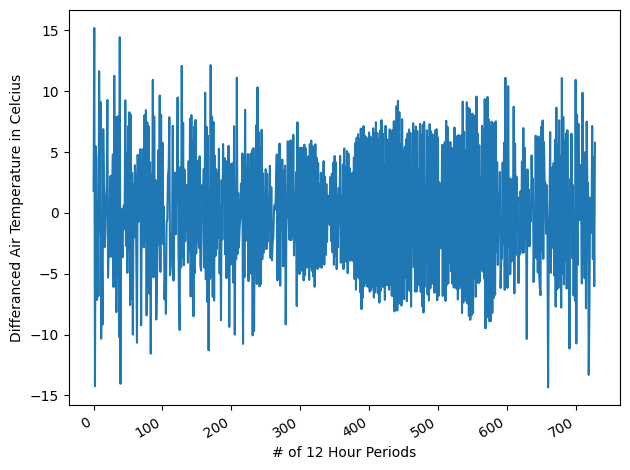

In [40]:
fig, ax = plt.subplots()

ax.plot(Tair_diff)
ax.set_xlabel('# of 12 Hour Periods')
ax.set_ylabel('Differanced Air Temperature in Celcius')


fig.autofmt_xdate()
plt.tight_layout()

# plt.savefig('figures/CH11_F_peixeiro.png', dpi=300)

### SARIMA(p,1,q)(P,1,Q)<sub>12<sub> 

In [41]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list):
        try: 
            model = SARIMAX(
                endog,
                exog,
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [52]:
ps = range(0, 2, 1)
qs = range(0, 2, 1)
Ps = range(0, 2, 1)
Qs = range(0, 2, 1)

order_list = list(product(ps, qs, Ps, Qs))

d = 1
D = 0
s = total_len

In [ ]:
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/16 [00:00<?, ?it/s]

In [44]:
result_array=SARIMA_result_df.to_numpy()

In [45]:
SARIMA_model = SARIMAX(train, order=(result_array[0][0][0], 1, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], total_len), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  609
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2319.605
Date:                Thu, 22 Jun 2023   AIC                           4641.211
Time:                        20:30:06   BIC                           4645.621
Sample:                             0   HQIC                          4642.927
                                - 609                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       120.5938     12.289      9.813      0.000      96.507     144.680
Ljung-Box (L1) (Q):                 533.12   Jarque-Bera (JB):                47.65
Prob(Q):                              0.00   Pr

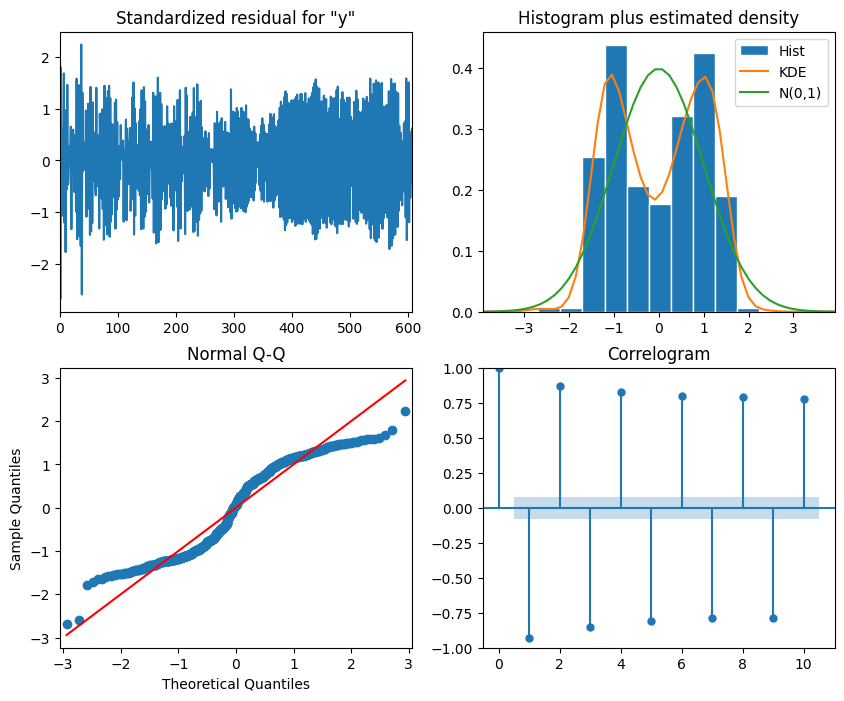

In [46]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [47]:
residuals = SARIMA_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(pvalue)

lb_pvalue


## Forecasting 

In [48]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    
    total_len = train_len + horizon
    end_idx = train_len

    if method == 'last_season':
        pred_last_season = []
        
        for i in range(train_len, total_len, window):
            last_season = Tair_diff[i-window:i]
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(Tair_diff[:i], order=(result_array[0][0][0], 1, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], total_len), simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
            
        return pred_SARIMA

In [49]:
pred_df = df[train_len:]

pred_df

,Ppt,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,
2015-11-01 12:00:00,0.0,17.449167,60.807500,1.363962,137.204167,275.164167
2015-11-02 00:00:00,0.0,13.869583,76.001667,0.890778,234.735000,131.722500
2015-11-02 12:00:00,0.0,22.602500,41.505833,1.279493,211.933333,285.664167
2015-11-03 00:00:00,0.0,15.985000,80.690833,1.824104,194.413333,130.285000
2015-11-03 12:00:00,0.0,21.667500,56.625000,2.052728,180.850000,283.131667
...,...,...,...,...,...,...
2015-12-29 12:00:00,0.0,7.232750,71.634167,1.425056,159.541667,133.169167
2015-12-30 00:00:00,0.0,3.447867,94.925000,0.638778,169.030000,51.092500
2015-12-30 12:00:00,0.0,8.032167,77.170833,1.137292,133.308333,176.881667


In [50]:
TRAIN_LEN = train_len
HORIZON = test_len
WINDOW = 60

pred_df['last_season'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'last_season')

pred_df.last

ValueError: Length of values (180) does not match length of index (121)

In [24]:
pred_df['SARIMA'] = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

pred_df

,ds,y,last_season,SARIMA
168,2005-07-01,15.829550,15.339097,16.749311
169,2005-08-01,17.554701,15.370764,16.684227
170,2005-09-01,18.100864,16.142005,17.188309
171,2005-10-01,17.496668,16.685754,18.088042
172,2005-11-01,19.347265,17.636728,18.656987
173,2005-12-01,20.031291,18.869325,19.947938
174,2006-01-01,23.486694,20.778723,22.074367
175,2006-02-01,12.536987,12.154552,13.743689
176,2006-03-01,15.467018,13.402392,15.086456
177,2006-04-01,14.233539,14.459239,15.655556


AttributeError: 'DataFrame' object has no attribute 'last_season'

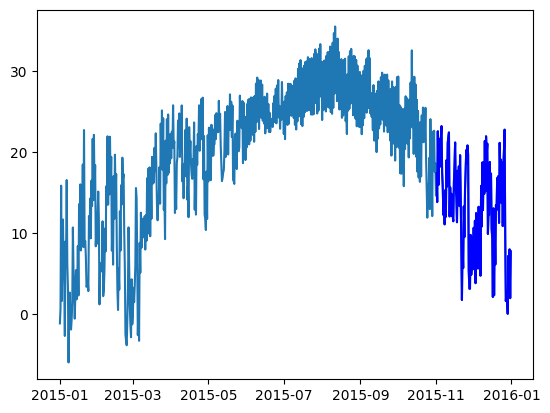

In [51]:
fig, ax = plt.subplots()

ax.plot(df.Tair)
ax.plot(pred_df.Tair, 'b-', label='actual')
ax.plot(pred_df.last_season, 'r:', label='naive seasonal')
ax.plot(pred_df.SARIMA, 'k--', label='SARIMA')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')
# ax.axvspan(168, 204, color='#808080', alpha=0.2)

# ax.legend(loc=2)

# plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
# plt.xlim(120, 204)

fig.autofmt_xdate()
plt.tight_layout()



## Evaluate 

In [27]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [28]:
mape_naive_seasonal = mape(pred_df.y, pred_df.last_season)
mape_SARIMA = mape(pred_df.y, pred_df.SARIMA)

print(mape_naive_seasonal, mape_SARIMA)

12.686561923100614 7.891649461191869


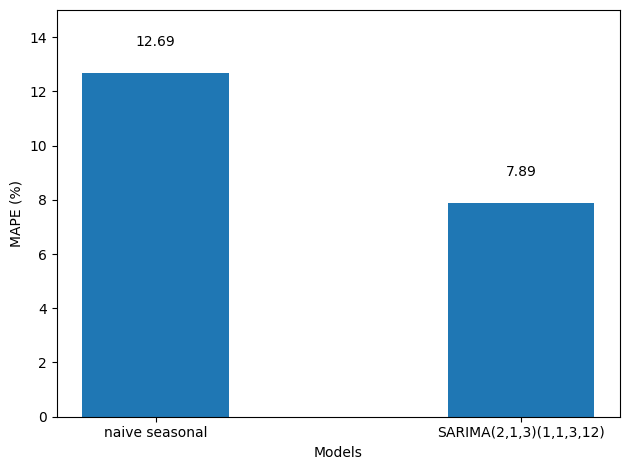

In [30]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'SARIMA']
y = [mape_naive_seasonal, mape_SARIMA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(round(value,2)), ha='center')

plt.tight_layout()

